In [2]:
import os
import cv2
import argparse
import numpy as np
import time
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from ImageConstruct import CImageUtils,CImageAlpha,CImageMFS
from DatasetConstruct import CDatasetConstruct
np.set_printoptions(suppress=True, precision=8)

In [3]:
df_train = pd.read_csv("../AI-Face-FairnessBench/dataset/train.csv")
real_file = df_train[df_train['Target'] == 0].iloc[10]['Image Path']
fake_file = df_train[df_train['Target'] == 1].iloc[10]['Image Path']
real_img = cv2.imread(real_file)
real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)
fake_img = cv2.imread(fake_file)
fake_img = cv2.cvtColor(fake_img, cv2.COLOR_BGR2RGB)
h, w = real_img.shape[:2]
fake_img = cv2.resize(fake_img, (w, h), interpolation=cv2.INTER_LINEAR)

In [4]:
len(df_train)

1317236

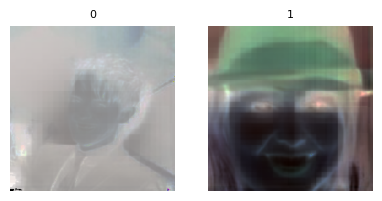

(244, 244, 3) (244, 244, 3)


In [32]:
real_alpha = CImageAlpha(real_img,isRes=True).get_raw_alpha()
fake_alpha = CImageAlpha(fake_img,isRes=True).get_raw_alpha()
CImageUtils.display([real_alpha,fake_alpha])
print(real_alpha.shape,fake_alpha.shape)

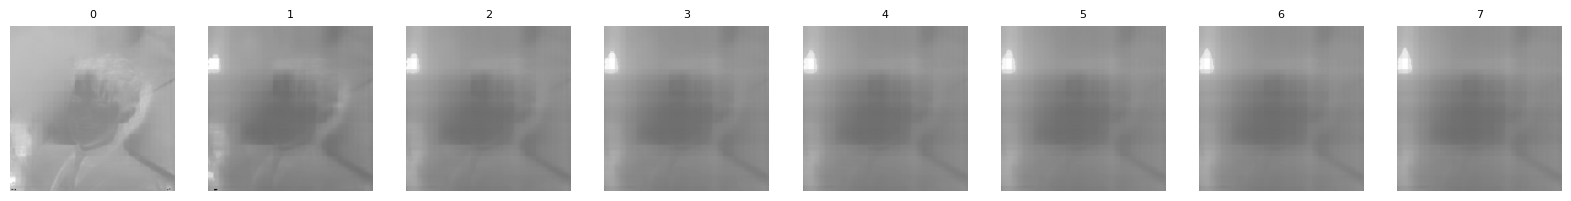

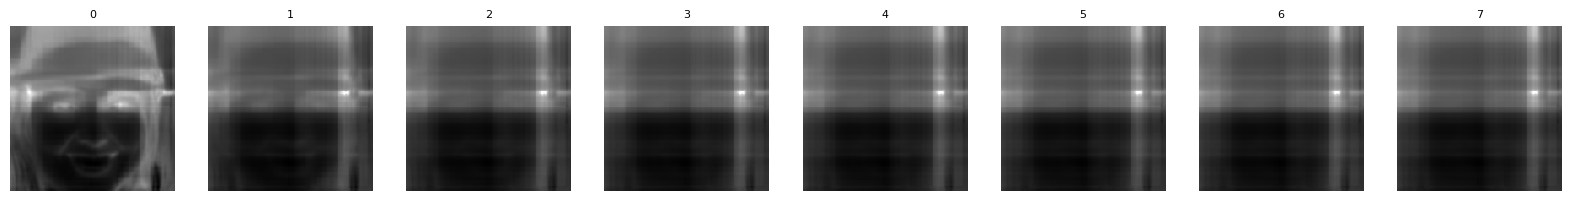

In [33]:
real_gray = CImageAlpha(real_img,isRes=True).get_gray_alpha(count=8)
fake_gray = CImageAlpha(fake_img,isRes=True).get_gray_alpha(count=8)
CImageUtils.display(real_gray)
CImageUtils.display(fake_gray)

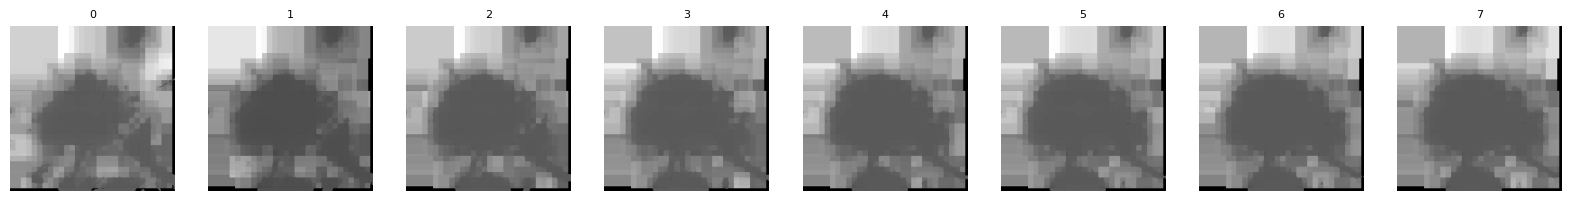

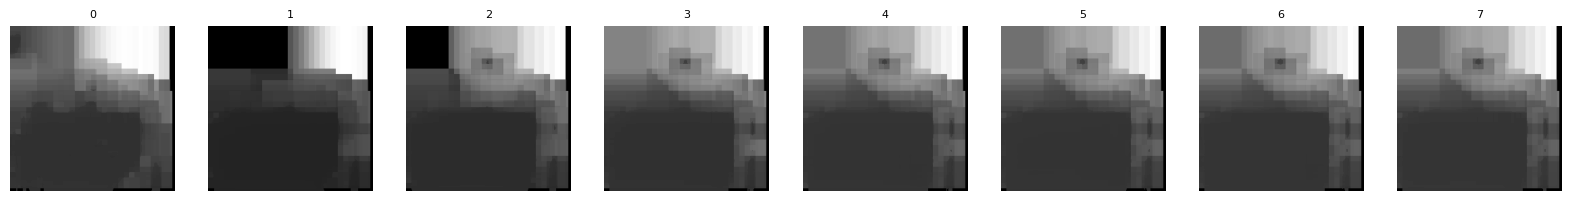

In [34]:
real_bin = CImageAlpha(real_img,isRes=True).get_bin_alpha(count=8)
fake_bin = CImageAlpha(fake_img,isRes=True).get_bin_alpha(count=8)
CImageUtils.display(real_bin)
CImageUtils.display(fake_bin)

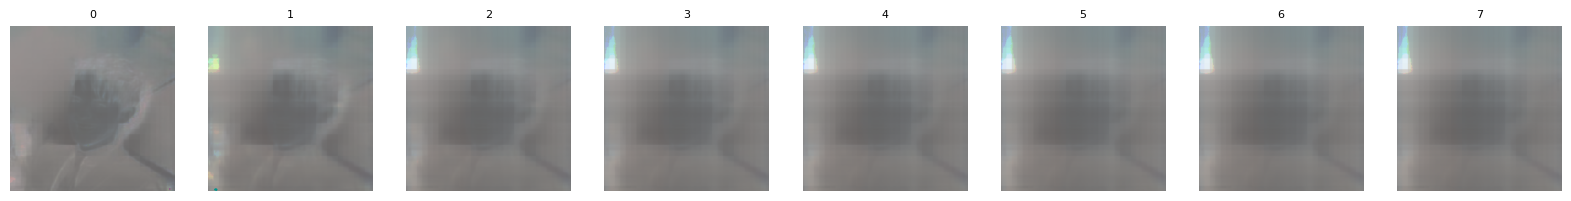

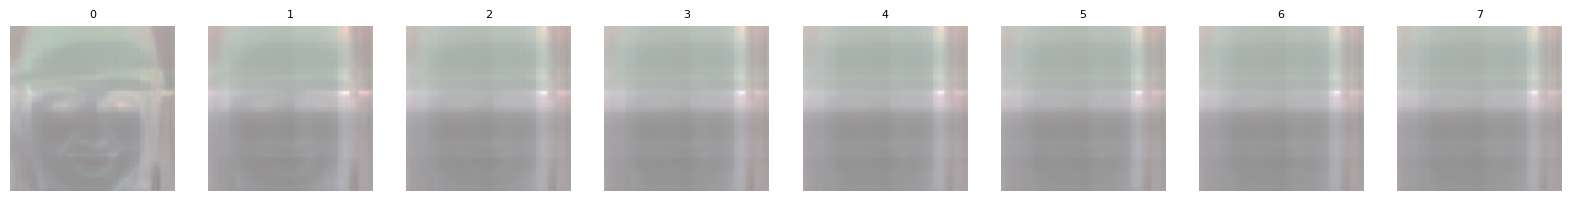

In [35]:
real_svd = CImageAlpha(real_img,isRes=True).get_svd_alpha(count=8)
fake_svd = CImageAlpha(fake_img,isRes=True).get_svd_alpha(count=8)
CImageUtils.display(real_svd)
CImageUtils.display(fake_svd)

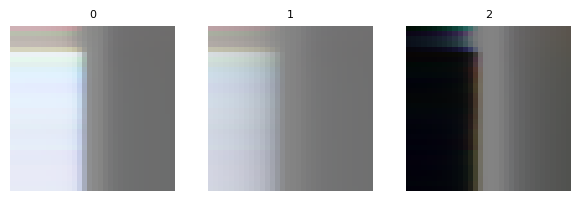

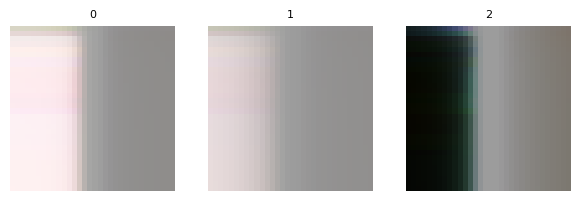

In [39]:
real_img_mfs = CImageMFS(real_img,isRes=True,count = 32).get_image_mfs()
fake_img_mfs = CImageMFS(fake_img,isRes=True,count = 32).get_image_mfs()
real_img_mfs = CImageUtils.normalize_by_channel(np.array(real_img_mfs))
fake_img_mfs = CImageUtils.normalize_by_channel(np.array(fake_img_mfs))
CImageUtils.display(real_img_mfs)
CImageUtils.display(fake_img_mfs)

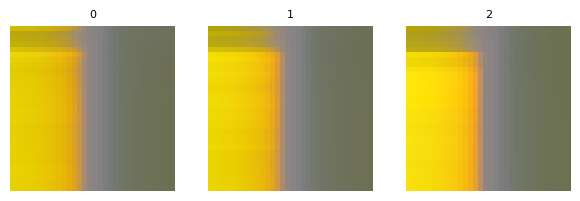

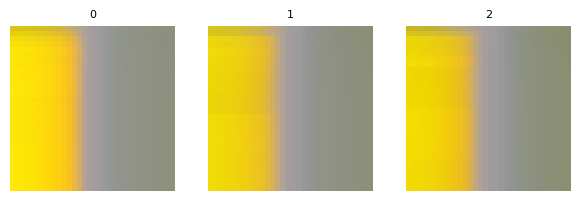

In [40]:
real_mfs_img = CImageMFS(real_img,isRes=True,count = 32).get_mfs_image()
fake_mfs_img = CImageMFS(fake_img,isRes=True,count = 32).get_mfs_image()
real_mfs_img = CImageUtils.normalize_by_channel(np.array(real_mfs_img))
fake_mfs_img = CImageUtils.normalize_by_channel(np.array(fake_mfs_img))
CImageUtils.display(real_mfs_img)
CImageUtils.display(fake_mfs_img)

In [41]:
from skimage.metrics import structural_similarity as ssim

img_real = real_alpha[0] #real_img_mfs[0].astype(np.float32)
img_fake = fake_alpha[0] #fake_img_mfs[0].astype(np.float32)

print(img_fake.shape)

# =========================
# 1. 像素统计
# =========================
print("=== 像素值统计 ===")
print(f"Real  - 均值: {np.mean(img_real):.6f}, 标准差: {np.std(img_real):.6f}")
print(f"Fake  - 均值: {np.mean(img_fake):.6f}, 标准差: {np.std(img_fake):.6f}")

# =========================
# 2. 差异统计
# =========================
diff = img_real - img_fake

print(f"\n=== 差异统计 ===")
print(f"差异均值: {np.mean(diff):.6f}")
print(f"差异标准差: {np.std(diff):.6f}")

# =========================
# 3. SSIM
# =========================
ssim_score, ssim_map = ssim(
    img_real,
    img_fake,
    full=True,
    channel_axis=-1,
    data_range=1.0
)

print(f"\n=== SSIM 结构相似性 ===")
print(f"SSIM: {ssim_score:.6f}")

if ssim_score < 0.70:
    print("评价: 差异很大")
elif ssim_score < 0.90:
    print("评价: 中等差异")
else:
    print("评价: 非常相似")

# =========================
# 4. 显著差异占比
# =========================
abs_diff = np.abs(diff)

threshold = 0.05   # 对 [0,1] 图像更合理

significant_diff_ratio = np.sum(abs_diff > threshold) / abs_diff.size

print(f"\n=== 显著差异占比 ===")
print(f"差异 > {threshold} 的像素占比: {significant_diff_ratio*100:.2f}%")

(244, 3)
=== 像素值统计 ===
Real  - 均值: 0.720181, 标准差: 0.049569
Fake  - 均值: 0.521847, 标准差: 0.129798

=== 差异统计 ===
差异均值: 0.198333
差异标准差: 0.140624

=== SSIM 结构相似性 ===
SSIM: 0.773479
评价: 中等差异

=== 显著差异占比 ===
差异 > 0.05 的像素占比: 92.08%
